In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
class BatsmanState(TypedDict):
    
    runs: int
    balls: int
    fours: int
    sixes: int
    
    strike_rate: float
    balls_per_boundary: float
    boundary_percent: float
    summary: str
    

In [3]:
def calculate_strike_rate(state: BatsmanState):
    
    sr = (state['runs'] / state['balls']) * 100
    
    state['strike_rate'] = round(sr, 2)
    
    return state

In [4]:
def calculate_balls_per_boundary(state: BatsmanState):
    
    bpd = state['balls'] / (state['fours'] + state['sixes'])
    
    state['balls_per_boundary'] = round(bpd, 2)
    
    return state

In [5]:
def calculate_boundary_percent(state: BatsmanState):
    
    bp = ((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs'] * 100
    
    state['boundary_percent'] = round(bp, 2)
    
    return state

In [6]:
def summary(state: BatsmanState):
    
    summary =  f"Batsman scored {state['runs']} runs off {state['balls']} balls with a strike rate of {state['strike_rate']},  hitting {state['fours']} fours and {state['sixes']} sixes. "

    state['summary'] = summary
    
    return state

In [9]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)


## edges

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percent')

## edges to summary
graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_balls_per_boundary', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

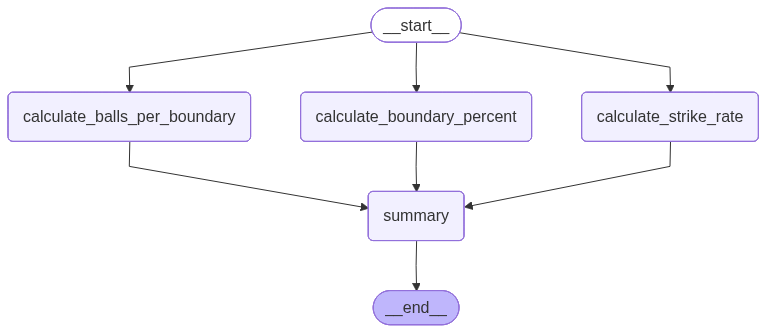

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
initial_state = {
    'runs': 85,
    'balls': 60,
    'fours': 8,
    'sixes': 4
}


workflow.invoke(initial_state)

## will throw error 

# This error occurs as we have send the state from START to multiple nodes in parallel, and then each of nodes are changing the state independently.
# So, langgraph thinks under the hood  runs are also being changed in parallel, which is not allowed. so we return the state partially only this fixes the issue.



InvalidUpdateError: At key 'runs': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [ ]:
def calculate_strike_rate(state: BatsmanState):
    
    sr = (state['runs'] / state['balls']) * 100
    
    # state['strike_rate'] = round(sr, 2)
    
    #### partial state update
    return {'strike_rate': round(sr, 2)}

In [13]:
def calculate_balls_per_boundary(state: BatsmanState):
    
    bpd = state['balls'] / (state['fours'] + state['sixes'])
    
    # state['balls_per_boundary'] = round(bpd, 2)
    
    return {'balls_per_boundary' : round(bpd, 2)}

In [14]:
def calculate_boundary_percent(state: BatsmanState):
    
    bp = ((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs'] * 100
    
    # state['boundary_percent'] = round(bp, 2)
    
    return {'boundary_percent': round(bp, 2)}

In [15]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)


## edges

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percent')

## edges to summary
graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_balls_per_boundary', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

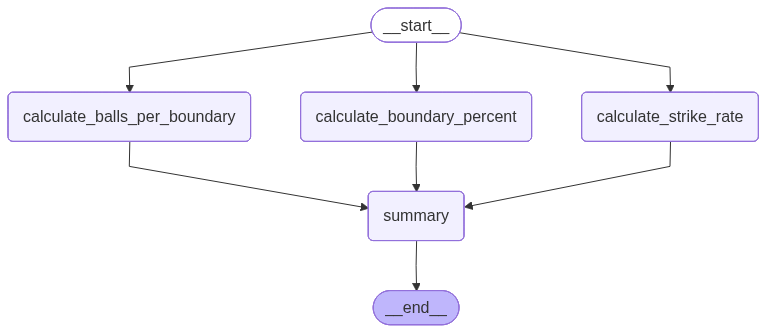

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [17]:
initial_state = {
    'runs': 85,
    'balls': 60,
    'fours': 8,
    'sixes': 4
}


workflow.invoke(initial_state)




{'runs': 85,
 'balls': 60,
 'fours': 8,
 'sixes': 4,
 'strike_rate': 141.67,
 'balls_per_boundary': 5.0,
 'boundary_percent': 65.88}